<div style="background-color: #0b2343; color: white; padding: 25px; font-family: Arial, sans-serif;">
    <h2 style="margin: 0; font-size: 24px; font-weight: normal;">
        Data Analytics & Machine Learning
    </h2>
    <h1 style="margin: 8px 0 0 0; font-size: 30px;">
        Parte 2: Reducción de Dimensionalidad y Aprendizaje No Supervisado
    </h1>
    <p style="margin: 12px 0 0 0; font-size: 16px; opacity: 0.9;">
        MIAX | Práctica B3-P3
    </p>
</div>

# 1. Objetivo, contexto y plan de trabajo

Partimos de la **Parte 1**, donde se construyó una matriz `X_clust` ya imputada y estandarizada a partir de métricas de rentabilidad, riesgo, forma de la distribución y exposiciones factoriales. En esta segunda parte el objetivo es utilizar esa matriz para identificar grupos de fondos con significado financiero y decidir cuáles encajan mejor con la tesis de inversión en **Asia Pacífico ex Japón**.

En esta Parte 2 no se recalculan features ni escalados; solo se consumen los artefactos generados en la Parte 1.

## Plan de resolución

1. Cargar los artefactos generados en la Parte 1 y verificar que `X_clust` ya está escalada.
2. Aplicar **PCA** para reducir dimensionalidad e interpretar qué factores resumen mejor la heterogeneidad del universo.
3. Ejecutar **K-Means** y **HAC** para construir clústeres desde dos lógicas distintas.
4. Comparar la estabilidad y el significado financiero de los grupos obtenidos.
5. Seleccionar los clústeres más coherentes con la tesis Asia utilizando reglas explícitas y trazables.
6. Exportar una tabla preparada para exploración visual externa en **Graphext**.
7. Utilizar el ETF **iShares MSCI All Country Asia ex Japan (AAXJ)** solo al final, como validación externa de las decisiones tomadas.

> Restricción metodológica importante: el ETF AAXJ no se utiliza para entrenar, calibrar ni seleccionar clústeres; se reserva exclusivamente para la validación final, tal y como exige el enunciado.

In [1]:
# ==============================================================
# BLOQUE 1: Librerías y configuración general
# ==============================================================
# Este bloque prepara todas las herramientas que vamos a usar en la práctica:
# - Gestión de rutas y ficheros del proyecto.
# - Carga de datos tabulares y objetos serializados.
# - Visualización de resultados.
# - Modelos de reducción de dimensionalidad y clustering.
# - Métricas para comparar soluciones no supervisadas.

from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

# Configuración visual homogénea para todas las figuras del notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Silenciamos advertencias no críticas para no ensuciar la narrativa del análisis.
warnings.filterwarnings("ignore")

# Detección robusta de rutas para que el notebook funcione tanto si se lanza
# desde la raíz del proyecto como desde la carpeta `src`.
ROOT = Path(".").resolve()

if (ROOT / "dataset").exists():
    DATASET_DIR = ROOT / "dataset"
    SRC_DIR = ROOT / "src"
elif (ROOT.parent / "dataset").exists():
    DATASET_DIR = ROOT.parent / "dataset"
    SRC_DIR = ROOT
else:
    raise FileNotFoundError(
        "No se encontró la carpeta `dataset` ni en el directorio actual ni en el directorio padre."
    )

print("Directorio actual detectado:", ROOT)
print("Directorio de datos detectado:", DATASET_DIR)


Directorio actual detectado: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\src
Directorio de datos detectado: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset


### Explicación del bloque

Este bloque fija el entorno de trabajo reproducible. Se importan las librerías necesarias para análisis cuantitativo, visualización y modelización no supervisada, y se definen rutas robustas para no depender del punto exacto desde el que se ejecute el notebook.

A nivel conceptual, aquí no se toma todavía ninguna decisión de inversión, pero sí una decisión técnica importante: mantener una única configuración visual y de rutas para que el análisis posterior sea consistente, legible y fácil de replicar.

In [2]:
# ==============================================================
# BLOQUE 2: Carga de artefactos de la Parte 1
# ==============================================================
# Recuperamos exactamente la base preparada en la Parte 1.
# Esto es importante porque el enunciado pide partir de los resultados previos
# y porque los algoritmos de clustering son muy sensibles a cambios en la escala.

features_path = DATASET_DIR / "features_fondos_part1.csv"
xclust_path = DATASET_DIR / "X_clust_part1.csv"
meta_path = DATASET_DIR / "X_clust_part1_metadata.json"

features_df = pd.read_csv(features_path)
X_clust_df = pd.read_csv(xclust_path)
xclust_meta = json.loads(meta_path.read_text(encoding="utf-8"))

# Verificamos la restricción heredada de la Parte 1: no debemos volver a escalar
# la matriz de clustering porque ya está transformada con StandardScaler.
if not xclust_meta.get("is_standardized", False):
    raise ValueError("La matriz X_clust no consta como estandarizada. Revisa la Parte 1 antes de continuar.")

if not xclust_meta.get("do_not_rescale_in_part2", False):
    raise ValueError("Los metadatos no confirman la regla de no reescalar en la Parte 2.")

# Separamos nombres base y nombres escalados para evitar confundir las variables
# originales interpretables con las columnas estandarizadas que alimentan PCA y clustering.
clustering_features = [col for col in X_clust_df.columns if col != "allfunds_id"]
X_clust_scaled_df = X_clust_df.rename(columns={col: f"{col}_scaled" for col in clustering_features})
scaled_feature_cols = [f"{col}_scaled" for col in clustering_features]

# Alineamos ambas tablas por `allfunds_id` para poder combinar interpretación
# financiera (variables originales) con aprendizaje no supervisado (variables escaladas).
analysis_df_full = features_df.merge(X_clust_scaled_df, on="allfunds_id", how="inner")
analysis_df_full = analysis_df_full.sort_values("allfunds_id").reset_index(drop=True)

print("Archivo de features:", features_path.name)
print("Archivo de clustering:", xclust_path.name)
print("Variables base usadas en clustering:", clustering_features)
print("Columnas escaladas usadas por los modelos:", scaled_feature_cols)
print("Dimensión de analysis_df_full:", analysis_df_full.shape)
display(analysis_df_full[["allfunds_id", "name_last", "ann_return", "ann_vol", "sharpe", "beta_mkt"]].head())


Archivo de features: features_fondos_part1.csv
Archivo de clustering: X_clust_part1.csv
Variables base usadas en clustering: ['ann_return', 'ann_vol', 'sharpe', 'sortino', 'max_drawdown', 'ret_skew', 'ret_kurt', 'beta_mkt', 'beta_smb', 'beta_hml', 'beta_wml']
Columnas escaladas usadas por los modelos: ['ann_return_scaled', 'ann_vol_scaled', 'sharpe_scaled', 'sortino_scaled', 'max_drawdown_scaled', 'ret_skew_scaled', 'ret_kurt_scaled', 'beta_mkt_scaled', 'beta_smb_scaled', 'beta_hml_scaled', 'beta_wml_scaled']
Dimensión de analysis_df_full: (24143, 32)


,allfunds_id,name_last,ann_return,ann_vol,sharpe,beta_mkt
0,8,"JANUS HENDERSON GLOBA ""A2"" (GBP)",0.185782,0.170803,0.940189,0.269912
1,9,"JANUS HENDERSON GLOBA ""A2"" (USD) J",0.172976,0.165519,0.904564,0.587186
2,12,"JANUS HENDERSON ABSOL ""A2"" (GBP)",0.019257,0.029606,0.310592,0.083100
3,19,"FRANKLIN BIOTECHNOLOGY DISCOVERY ""I""",0.094107,0.265020,0.302164,0.386640
4,20,"TEMPLETON EUROPEAN OP ""I"" (EUR)",0.016817,0.169107,0.040229,0.658240


Nulos en X_clust ya fusionada: 0
Infinitos en X_clust ya fusionada: 0


,count,mean,std,min,10%,50%,90%,max
ann_return,24143.0,0.079991,0.097657,-0.335091,-0.001422,0.057167,0.180526,2.214202
ann_vol,24143.0,0.122422,0.090211,0.000000,0.031512,0.110404,0.208113,1.410802
sharpe,24126.0,0.045350,10.383220,-1494.938473,-0.268389,0.459307,0.929423,7.319692
sortino,24111.0,-0.095293,25.223623,-3549.539483,-0.272179,0.523501,1.082524,222.477971
max_drawdown,24143.0,-0.254891,0.126463,-0.827011,-0.410220,-0.263909,-0.086832,0.000000
beta_mkt,24143.0,0.435229,0.324664,-0.699973,0.039143,0.390336,0.892621,1.792090
beta_smb,24143.0,0.118560,0.210622,-1.472067,-0.117550,0.104189,0.349063,2.052904
beta_hml,24143.0,-0.016021,0.154696,-1.058818,-0.213744,0.000392,0.140210,1.143186
beta_wml,24143.0,0.041505,0.115182,-0.747711,-0.058190,0.020811,0.179236,0.994109


Umbral max_abs_scaled: 6.0
Umbral l2_scaled (P99.9): 21.0711
Fondos totales antes de limpiar outliers: 24143
Fondos excluidos como outliers de clustering: 305
Fondos retenidos para PCA y clustering: 23838
Archivo con outliers excluidos: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\outliers_clustering_part2.csv


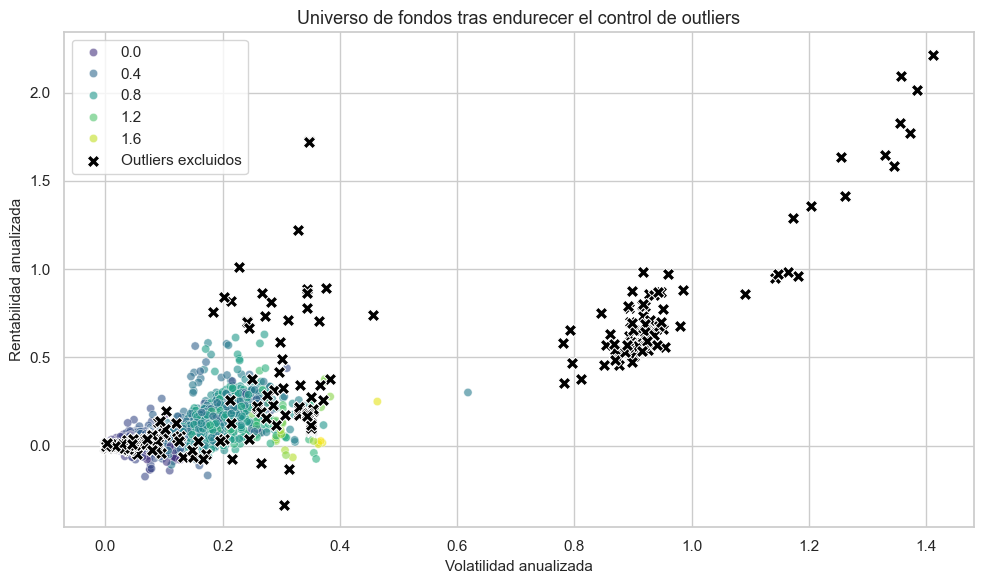

In [3]:
# ==============================================================
# BLOQUE 3: Auditoría rápida de la base analítica y control de outliers
# ==============================================================
# Esta comprobación nos asegura que la matriz está preparada para algoritmos
# de distancia euclídea y nos da intuición económica sobre el universo de fondos.
#
# Además, endurecemos el tratamiento de outliers directamente en el espacio
# estandarizado de la Parte 1. Esto es coherente con el objetivo del clustering:
# evitar que unas pocas observaciones extremas deformen centroides o generen
# clústeres unitarios poco útiles para la interpretación financiera.

scaled_nulls = analysis_df_full[scaled_feature_cols].isna().sum().sum()
scaled_inf = np.isinf(analysis_df_full[scaled_feature_cols].to_numpy(dtype=float)).sum()

print("Nulos en X_clust ya fusionada:", int(scaled_nulls))
print("Infinitos en X_clust ya fusionada:", int(scaled_inf))

summary_cols = ["ann_return", "ann_vol", "sharpe", "sortino", "max_drawdown", "beta_mkt", "beta_smb", "beta_hml", "beta_wml"]
display(analysis_df_full[summary_cols].describe(percentiles=[0.1, 0.5, 0.9]).T)

# ----------------------------------------------------------------
# Regla robusta de exclusión de outliers en el espacio de modelización
# ----------------------------------------------------------------
# Como X_clust ya está estandarizada, un valor absoluto muy alto en una variable
# indica una observación extraordinariamente extrema respecto al universo.
# Usamos dos criterios complementarios:
# - max_abs_scaled > 6: valor extremo en al menos una dimensión.
# - l2_scaled > percentil 99.9: alejamiento multivariante extremo del centro.
#
# La combinación endurece la limpieza sin depender solo de una columna concreta.
scaled_matrix_full = analysis_df_full[scaled_feature_cols].to_numpy(dtype=float)
analysis_df_full["max_abs_scaled"] = np.abs(scaled_matrix_full).max(axis=1)
analysis_df_full["l2_scaled"] = np.sqrt((scaled_matrix_full ** 2).sum(axis=1))

l2_cut = analysis_df_full["l2_scaled"].quantile(0.999)
max_abs_cut = 6.0

outlier_mask = (analysis_df_full["max_abs_scaled"] > max_abs_cut) | (analysis_df_full["l2_scaled"] > l2_cut)
analysis_df_full["outlier_clustering_flag"] = outlier_mask.astype(int)

analysis_df = analysis_df_full.loc[~outlier_mask].copy()
analysis_df = analysis_df.reset_index(drop=True)
X = analysis_df[scaled_feature_cols].to_numpy(dtype=float)

outliers_df = analysis_df_full.loc[outlier_mask].copy()
outliers_path = DATASET_DIR / "outliers_clustering_part2.csv"
outliers_df.to_csv(outliers_path, index=False, encoding="utf-8")

print("Umbral max_abs_scaled:", max_abs_cut)
print("Umbral l2_scaled (P99.9):", round(float(l2_cut), 4))
print("Fondos totales antes de limpiar outliers:", len(analysis_df_full))
print("Fondos excluidos como outliers de clustering:", int(outlier_mask.sum()))
print("Fondos retenidos para PCA y clustering:", len(analysis_df))
print("Archivo con outliers excluidos:", outliers_path)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=analysis_df.sample(min(len(analysis_df), 4000), random_state=42),
    x="ann_vol",
    y="ann_return",
    hue="beta_mkt",
    palette="viridis",
    alpha=0.60
)
if len(outliers_df) > 0:
    sns.scatterplot(
        data=outliers_df.sample(min(len(outliers_df), 500), random_state=42),
        x="ann_vol",
        y="ann_return",
        color="black",
        marker="X",
        s=80,
        label="Outliers excluidos"
    )
plt.title("Universo de fondos tras endurecer el control de outliers")
plt.xlabel("Volatilidad anualizada")
plt.ylabel("Rentabilidad anualizada")
plt.tight_layout()
plt.show()


### Explicación del bloque

Aquí se recupera la materia prima real de la práctica: una tabla interpretable con métricas financieras por fondo y una matriz `X_clust` ya preparada para algoritmos de agrupamiento. La comprobación de que no quedan nulos ni infinitos es clave porque métodos como PCA, K-Means o HAC requieren entradas numéricas limpias.

La decisión metodológica más importante sigue siendo **no volver a escalar** la matriz. Además, en esta versión endurecemos el tratamiento de outliers en el espacio ya estandarizado. La lógica es financiera y estadística a la vez: si unas pocas observaciones extremadamente alejadas dominan las distancias, el clustering termina describiendo anomalías puntuales en lugar de estilos de fondos comparables. Se aplican dos criterios complementarios de detección de outliers sobre el espacio estandarizado:

+ Un criterio univariante (max_abs_scaled > 6), que detecta valores extremadamente atípicos en alguna variable individual.
+ Un criterio multivariante (l2_scaled > P99.9), que identifica observaciones globalmente alejadas del centro del espacio, aunque ninguna variable individual sea extrema.

Este doble enfoque permite capturar tanto outliers evidentes como combinaciones inusuales de características, evitando que estos casos distorsionen la estructura del análisis de PCA y clustering.

No hacer esto produjo en unas primeras pruebas clusteres de tamaño 1. Si un puñado de fondos presenta ratios o perfiles de riesgo-retorno tan extremos que fuerzan clústeres de tamaño uno, esos casos aportan más ruido que señal para la segmentación estratégica del universo. Mantenerlos dentro del ajuste sesgó centroides, distancias y fronteras de agrupación, y nos llevó a sobreinterpretar excepciones en vez de patrones repetibles.

Por eso la exclusión de outliers se plantea como una limpieza analítica. Los fondos excluidos no desaparecen del estudio: se exportan a un fichero específico y quedan documentados. Así se conserva trazabilidad completa y se puede explicar que fueron apartados del clustering precisamente para mejorar la estabilidad, la interpretabilidad económica y la utilidad práctica de los clústeres obtenidos.

Los outliers no se excluyen porque sean “malos fondos”, sino porque pueden deformar las técnicas geométricas que buscan familias comparables.La exclusión no implica que esos fondos carezcan de interés económico, sino que su perfil extremo puede desestabilizar métodos basados en distancias y ocultar la estructura predominante del universo. El filtrado se realiza en el espacio estandarizado precisamente para que la noción de “extremo” sea comparable entre variables heterogéneas.


Número de componentes para alcanzar el 85 % de varianza: 4


,Componente,Varianza explicada,Varianza acumulada
0,1,0.394731,0.394731
1,2,0.268789,0.663520
2,3,0.106098,0.769618
3,4,0.089700,0.859318
4,5,0.059991,0.919309
5,6,0.030851,0.950159
6,7,0.023143,0.973303
7,8,0.010997,0.984300
8,9,0.009290,0.993590
9,10,0.006014,0.999604


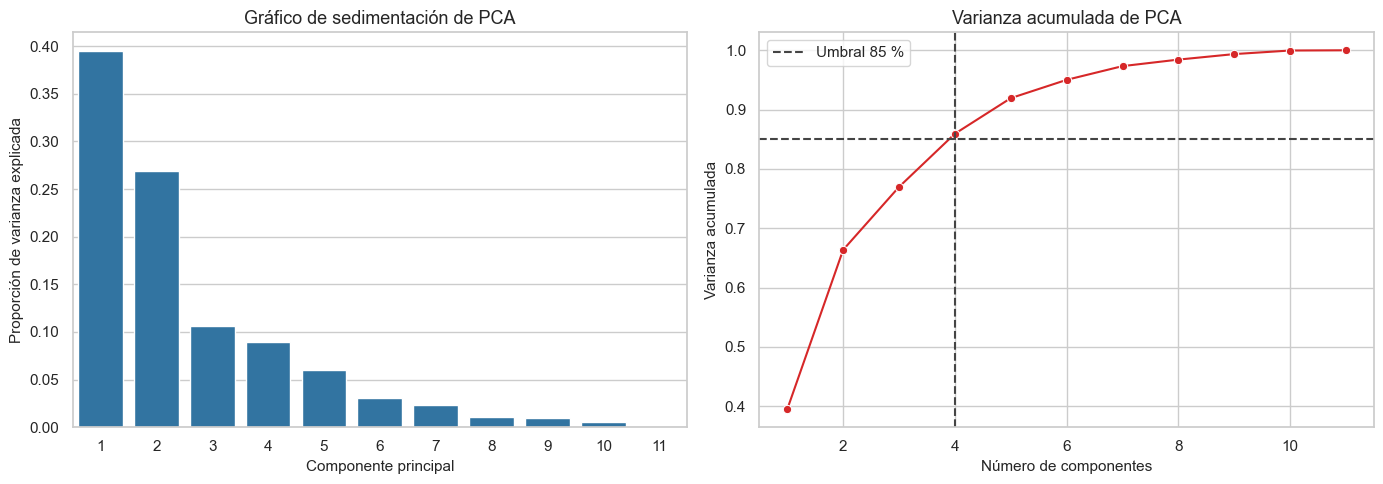

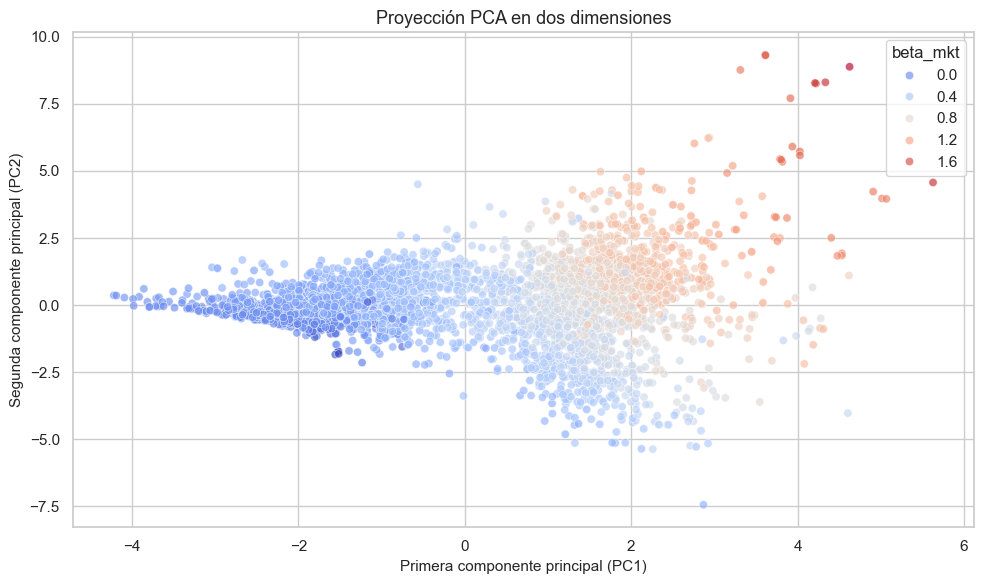

In [4]:
# ==============================================================
# BLOQUE 4: PCA para reducción de dimensionalidad
# ==============================================================
# PCA busca nuevas variables ortogonales (componentes principales) que capturen
# la mayor parte de la variabilidad del universo con menos dimensiones.

pca_full = PCA()
pca_scores = pca_full.fit_transform(X)

explained_df = pd.DataFrame({
    "Componente": np.arange(1, len(clustering_features) + 1),
    "Varianza explicada": pca_full.explained_variance_ratio_,
    "Varianza acumulada": np.cumsum(pca_full.explained_variance_ratio_)
})

# Elegimos el número mínimo de componentes que explica al menos el 85 %
# de la variabilidad. Es un umbral práctico: reduce dimensión sin perder
# demasiada información estructural del universo.
n_components_85 = int(np.argmax(explained_df["Varianza acumulada"].to_numpy() >= 0.85) + 1)

pc_cols = [f"PC{i}" for i in range(1, pca_scores.shape[1] + 1)]
pcs_df = pd.DataFrame(pca_scores, columns=pc_cols)
analysis_df = pd.concat([analysis_df, pcs_df], axis=1)

print("Número de componentes para alcanzar el 85 % de varianza:", n_components_85)
display(explained_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=explained_df, x="Componente", y="Varianza explicada", color="#1f77b4", ax=axes[0])
axes[0].set_title("Gráfico de sedimentación de PCA")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Proporción de varianza explicada")

sns.lineplot(data=explained_df, x="Componente", y="Varianza acumulada", marker="o", ax=axes[1], color="#d62728")
axes[1].axhline(0.85, linestyle="--", color="#444444", label="Umbral 85 %")
axes[1].axvline(n_components_85, linestyle="--", color="#444444")
axes[1].set_title("Varianza acumulada de PCA")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=analysis_df.sample(min(len(analysis_df), 4000), random_state=42),
    x="PC1",
    y="PC2",
    hue="beta_mkt",
    palette="coolwarm",
    alpha=0.65
)
plt.title("Proyección PCA en dos dimensiones")
plt.xlabel("Primera componente principal (PC1)")
plt.ylabel("Segunda componente principal (PC2)")
plt.tight_layout()
plt.show()


## Interpretación del PCA: varianza explicada y proyección en 2D

### 1. Varianza explicada y selección de componentes

El gráfico de varianza acumulada confirma que:

- Con **4 componentes principales** se alcanza aproximadamente el **85 % de la varianza total**.
- A partir de ese punto, las ganancias en información son decrecientes.

Este umbral del 85 % se adopta como un compromiso práctico entre:
- reducción de dimensionalidad,
- y preservación de la estructura estadística relevante.

No obstante, es importante destacar que **más varianza explicada no implica necesariamente mayor relevancia económica**, por lo que la interpretación posterior de las componentes es fundamental.

### 2. Estructura geométrica del universo (PC1 vs PC2)

La proyección en las dos primeras componentes principales permite visualizar la distribución de los fondos en un espacio bidimensional.

Se observan varios aspectos relevantes:

#### Gradiente claro en PC1
- Existe una estructura continua de izquierda a derecha.
- El color (beta de mercado) muestra un patrón muy claro:
  - Fondos con **beta baja o negativa** se sitúan en la parte izquierda.
  - Fondos con **beta alta** se concentran en la parte derecha.

Esto sugiere que **PC1 está fuertemente asociado a la exposición al mercado (beta_mkt)**, actuando como un eje de riesgo sistemático.

#### Dispersión vertical en PC2
- PC2 introduce una segunda dimensión que separa fondos con perfiles distintos aun teniendo betas similares.
- Esta componente probablemente está capturando diferencias relacionadas con:
  - volatilidad,
  - drawdown,
  - calidad del retorno (Sharpe/Sortino),
  - u otros factores no puramente direccionales.

#### Estructura no aleatoria
- La nube de puntos no es uniforme ni circular, sino que presenta forma de abanico/triángulo.
- Esto indica que el universo de fondos tiene **estructura latente**, no ruido puro.---

### 3. Implicaciones para el análisis posterior

Estos resultados tienen varias consecuencias importantes:

- El PCA confirma que el universo puede describirse con pocas dimensiones relevantes.
- La fuerte relación entre PC1 y beta_mkt sugiere que el riesgo de mercado es un eje dominante.
- La existencia de estructura visible en el plano PC1–PC2 justifica la aplicación de técnicas de clustering, ya que es probable que existan grupos diferenciados de fondos.

En este contexto, PCA no sustituye al clustering, sino que:
- facilita la visualización,
- reduce ruido,
- y ayuda a interpretar la segmentación posterior.


Variables más influyentes en PC1:


,PC1
beta_mkt,0.539593
ann_vol,0.459874
ann_return,0.349266
ret_skew,0.183354
max_drawdown,-0.516263



Variables más influyentes en PC2:


,PC2
beta_smb,0.607036
beta_hml,0.583958
beta_mkt,0.215762
ann_return,-0.184004
beta_wml,-0.430324



Variables más influyentes en PC3:


,PC3
ret_skew,0.785670
max_drawdown,0.227000
beta_mkt,-0.103890
beta_wml,-0.224220
ret_kurt,-0.514191



Variables más influyentes en PC4:


,PC4
beta_wml,0.751312
beta_hml,0.516934
max_drawdown,0.296379
ann_return,0.201323
beta_smb,0.157220


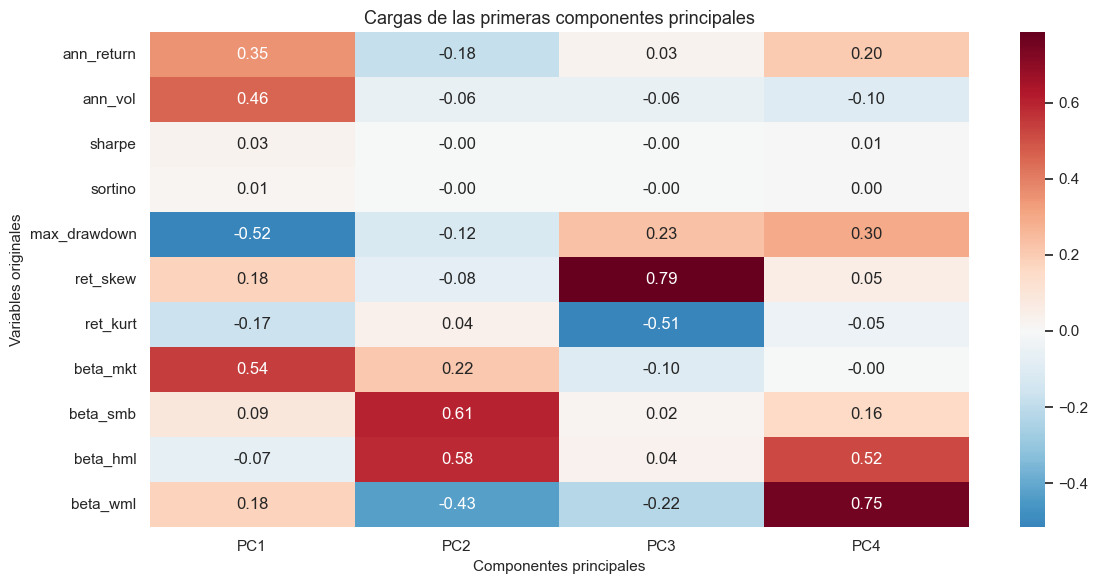

In [5]:
# ==============================================================
# BLOQUE 5: Interpretación de componentes principales
# ==============================================================
# Las cargas factoriales indican cuánto pesa cada variable original en cada
# componente. Son la clave para dar sentido financiero a PCA.

loadings = pd.DataFrame(
    pca_full.components_.T,
    index=clustering_features,
    columns=[f"PC{i}" for i in range(1, len(clustering_features) + 1)]
)

# Mostramos las variables con mayor contribución absoluta a las primeras
# componentes porque suelen ser las más interpretables económicamente.
for component in ["PC1", "PC2", "PC3", "PC4"]:
    top_loadings = loadings[component].abs().sort_values(ascending=False).head(5).index.tolist()
    print(f"\nVariables más influyentes en {component}:")
    display(loadings.loc[top_loadings, [component]].sort_values(component, ascending=False))

plt.figure(figsize=(12, 6))
sns.heatmap(loadings.iloc[:, :min(4, loadings.shape[1])], cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("Cargas de las primeras componentes principales")
plt.xlabel("Componentes principales")
plt.ylabel("Variables originales")
plt.tight_layout()
plt.show()


## Interpretación financiera de las componentes principales (loadings)

La matriz de cargas (loadings) permite interpretar cada componente principal como una combinación lineal de las variables originales. A diferencia de la varianza explicada, que es una medida puramente estadística, los loadings permiten asignar un **significado económico** a cada dimensión del espacio reducido.

Es importante recordar que:
- El **signo de las componentes es arbitrario** (puede invertirse sin cambiar su significado geométrico).
- La interpretación se basa en el **peso relativo de las variables**, no en su valor absoluto aislado.

### 1. Primera componente principal (PC1): Riesgo sistemático y perfil retorno-riesgo

Variables dominantes:
- beta_mkt (+)
- ann_vol (+)
- ann_return (+)
- max_drawdown (−)
- ret_skew (+)

PC1 está claramente asociada a la **exposición al mercado (riesgo sistemático)** y al nivel general de riesgo asumido por el fondo.

- Valores altos de PC1 corresponden a fondos:
  - con mayor beta,
  - mayor volatilidad,
  - mayor retorno esperado,
  - y menor impacto relativo de drawdowns.

- Valores bajos de PC1 corresponden a perfiles más defensivos.

En términos financieros, PC1 puede interpretarse como un eje de:
> **"exposición al mercado / agresividad del perfil de inversión"**

### 2. Segunda componente principal (PC2): Sesgo factorial value–size vs momentum

Variables dominantes:
- beta_smb (+)
- beta_hml (+)
- beta_wml (−)
- beta_mkt (+, menor peso)
- ann_return (−)

PC2 captura principalmente una **estructura factorial clásica**:

- Lado positivo:
  - exposición a factores **SMB (small cap)** y **HML (value)**

- Lado negativo:
  - exposición a **momentum (WML)**

Esto define un eje de estilo de inversión:

> **"value/small caps vs momentum"**

Es una dimensión muy relevante en gestión de carteras, ya que distingue entre estrategias basadas en valoración fundamental frente a estrategias de tendencia.

### 3. Tercera componente principal (PC3): Asimetría y forma de la distribución de retornos

Variables dominantes:
- ret_skew (+)
- ret_kurt (−)
- max_drawdown (+)
- beta_wml (−, menor peso)

PC3 está fuertemente dominada por variables de **forma de la distribución de retornos**:

- alta asimetría (skewness),
- menor curtosis (colas menos extremas),
- relación con drawdowns.

Esto sugiere que esta componente captura:

> **"calidad estadística del retorno / perfil de cola de riesgos"**

Diferencia entre fondos:
- con retornos más estables o asimétricos positivos,
- frente a fondos con colas más pesadas o riesgos extremos.

### 4. Cuarta componente principal (PC4): Momentum y exposición combinada a factores

Variables dominantes:
- beta_wml (+)
- beta_hml (+)
- max_drawdown (+)
- ann_return (+)
- beta_smb (+)

PC4 introduce una dimensión adicional relacionada con:

- exposición a **momentum**,
- combinada con factores tradicionales (value y size),
- y cierta relación con rendimiento y drawdown.

Puede interpretarse como un eje de:

> **"intensidad de exposición a factores dinámicos (momentum) y combinaciones factoriales"**

Mejor k según silhouette y apoyo de Davies-Bouldin: 3


,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,117403.913125,0.333788,11204.851790,1.272199
1,3,92198.303714,0.349057,10391.807358,1.200520
2,4,81628.069690,0.293037,8853.427244,1.232908
3,5,73465.990433,0.269735,8039.447275,1.394687
4,6,66707.586307,0.280947,7565.760204,1.264867
5,7,61225.834306,0.242279,7224.612014,1.299619
6,8,58115.068978,0.223911,6705.953465,1.382276


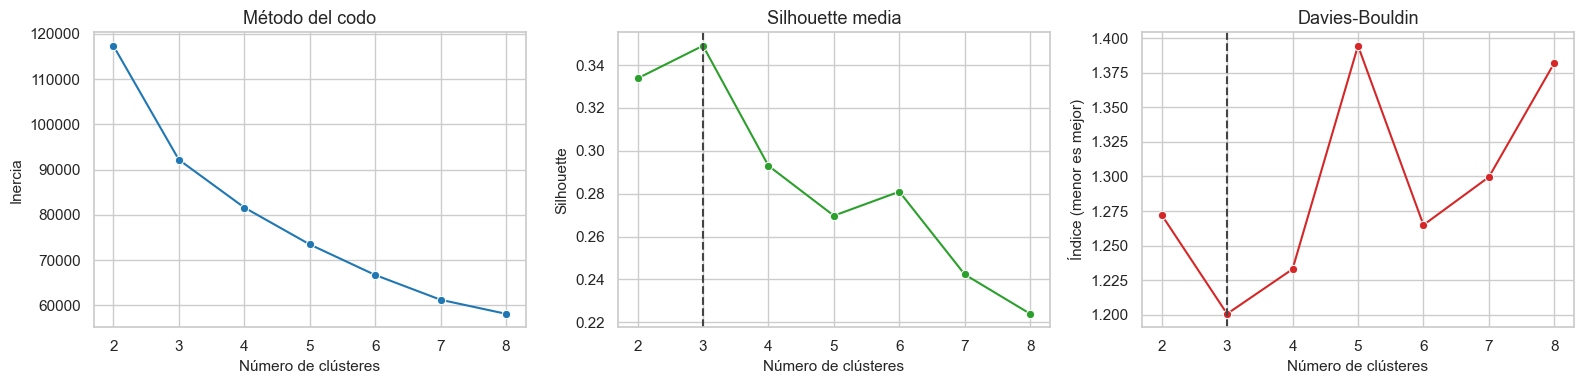

In [6]:
# ==============================================================
# BLOQUE 6: Selección del número de clústeres para K-Means
# ==============================================================
# Probamos varios valores de k y comparamos tres métricas:
# - Silhouette: mayor es mejor.
# - Calinski-Harabasz: mayor es mejor.
# - Davies-Bouldin: menor es mejor.

k_grid = list(range(2, 9))
kmeans_eval_rows = []

for k in k_grid:
    model = KMeans(n_clusters=k, n_init=25, random_state=42)
    labels = model.fit_predict(X)

    kmeans_eval_rows.append({
        "k": k,
        "inercia": model.inertia_,
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    })

kmeans_eval_df = pd.DataFrame(kmeans_eval_rows)
best_k = int(kmeans_eval_df.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["k"])

print("Mejor k según silhouette y apoyo de Davies-Bouldin:", best_k)
display(kmeans_eval_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=kmeans_eval_df, x="k", y="inercia", marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clústeres")
axes[0].set_ylabel("Inercia")

sns.lineplot(data=kmeans_eval_df, x="k", y="silhouette", marker="o", ax=axes[1], color="#2ca02c")
axes[1].axvline(best_k, linestyle="--", color="#444444")
axes[1].set_title("Silhouette media")
axes[1].set_xlabel("Número de clústeres")
axes[1].set_ylabel("Silhouette")

sns.lineplot(data=kmeans_eval_df, x="k", y="davies_bouldin", marker="o", ax=axes[2], color="#d62728")
axes[2].axvline(best_k, linestyle="--", color="#444444")
axes[2].set_title("Davies-Bouldin")
axes[2].set_xlabel("Número de clústeres")
axes[2].set_ylabel("Índice (menor es mejor)")

plt.tight_layout()
plt.show()


## Selección del número óptimo de clústeres (K-Means)

El algoritmo K-Means requiere definir previamente el número de clústeres \(k\). Dado que esta información no es conocida a priori, se evalúan diferentes valores de \(k\) utilizando métricas internas de calidad del clustering.

Se consideran tres métricas complementarias:

- **Silhouette Score**: mide la separación entre clústeres (mayor es mejor).
- **Calinski-Harabasz Index**: evalúa la compacidad y separación (mayor es mejor).
- **Davies-Bouldin Index**: penaliza solapamiento entre clústeres (menor es mejor).

Adicionalmente, se analiza la **inercia (método del codo)** para detectar puntos de saturación en la reducción del error intra-cluster.

Es importante destacar que:

- No existe un único criterio óptimo universal.
- Diferentes métricas pueden sugerir valores distintos de \(k\).
- La elección final combina evidencia cuantitativa con interpretabilidad económica.

El objetivo no es únicamente maximizar una métrica, sino identificar una segmentación que sea:
- estadísticamente consistente,
- y financieramente interpretable.

Tamaño de cada clúster K-Means:


,ann_return,ann_vol,sharpe,sortino,max_drawdown,beta_mkt,beta_smb,beta_hml,beta_wml,n_fondos
cluster_kmeans,,,,,,,,,,
0,0.103351,0.175134,0.506499,0.607509,-0.363498,0.800309,0.239367,0.045204,0.022047,7168
1,0.142740,0.184061,0.679055,0.799521,-0.329369,0.548316,-0.101925,-0.212637,0.145009,4651
2,0.023855,0.053060,0.272201,0.295056,-0.152098,0.156331,0.097150,0.006193,0.006775,12019


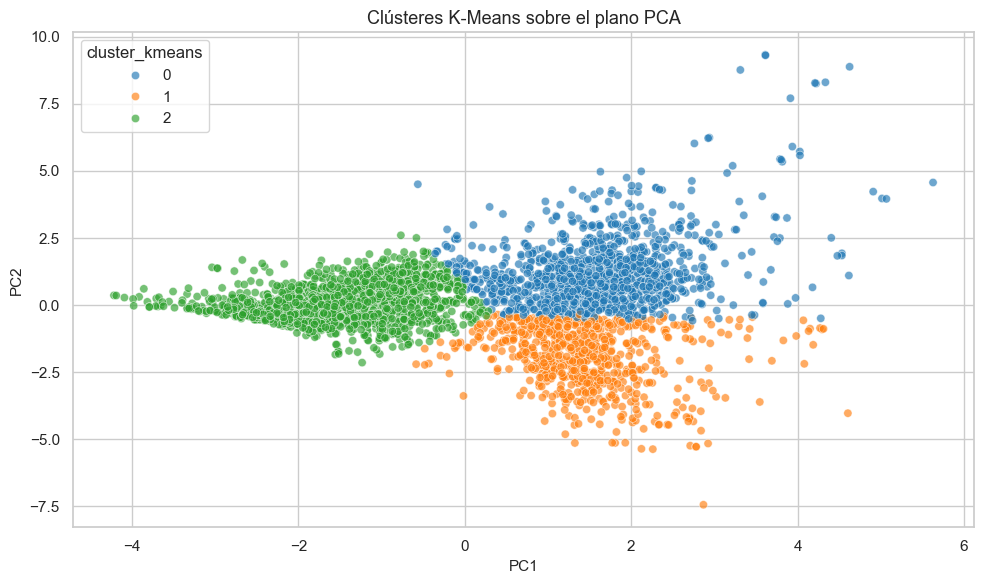

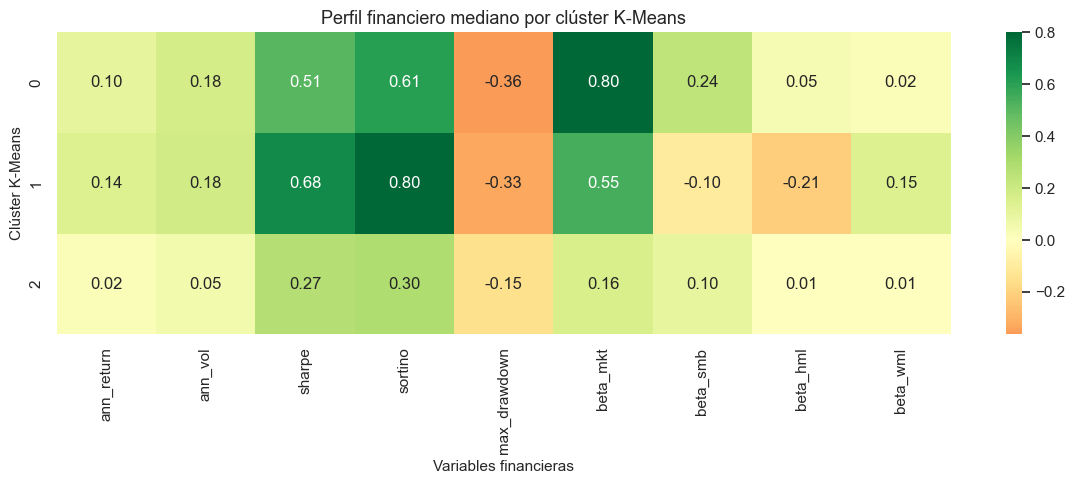

In [7]:
# ==============================================================
# BLOQUE 7: Ajuste final de K-Means e interpretación de perfiles
# ==============================================================
# Entrenamos el modelo definitivo con el valor de k elegido y pasamos del
# resultado estadístico a un perfil financiero interpretable por clúster.

kmeans = KMeans(n_clusters=best_k, n_init=25, random_state=42)
analysis_df["cluster_kmeans"] = kmeans.fit_predict(X)

profile_cols = ["ann_return", "ann_vol", "sharpe", "sortino", "max_drawdown", "beta_mkt", "beta_smb", "beta_hml", "beta_wml"]

cluster_profile_kmeans = analysis_df.groupby("cluster_kmeans")[profile_cols].median().sort_index()
cluster_sizes_kmeans = analysis_df["cluster_kmeans"].value_counts().sort_index().rename("n_fondos")
cluster_profile_kmeans = cluster_profile_kmeans.join(cluster_sizes_kmeans)

print("Tamaño de cada clúster K-Means:")
display(cluster_profile_kmeans)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=analysis_df.sample(min(len(analysis_df), 4000), random_state=42),
    x="PC1",
    y="PC2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.65
)
plt.title("Clústeres K-Means sobre el plano PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile_kmeans[profile_cols], cmap="RdYlGn", center=0, annot=True, fmt=".2f")
plt.title("Perfil financiero mediano por clúster K-Means")
plt.xlabel("Variables financieras")
plt.ylabel("Clúster K-Means")
plt.tight_layout()
plt.show()


## Ajuste final de K-Means e interpretación de clústeres

Una vez seleccionado el número óptimo de clústeres, se ajusta el modelo K-Means sobre la matriz de variables estandarizadas.

Cada fondo queda asignado a un clúster, lo que permite transformar el espacio continuo en una segmentación discreta del universo.

### Perfilado de clústeres

Para interpretar cada grupo, se calcula la mediana de las variables financieras relevantes:

- retorno anual (ann_return)
- volatilidad (ann_vol)
- ratios de calidad (Sharpe, Sortino)
- drawdown máximo
- exposiciones factoriales (betas)

Se utiliza la **mediana en lugar de la media** para evitar que valores extremos distorsionen la caracterización del grupo.

### Visualización en espacio PCA

La representación en el plano (PC1, PC2) permite observar:

- separación entre clústeres,
- posibles solapamientos,
- coherencia con la estructura previamente identificada en PCA.

### Interpretación económica

Cada clúster debe entenderse como un **perfil de inversión** caracterizado por:

- nivel de exposición al mercado,
- estilo factorial (value, momentum, size),
- perfil de riesgo (volatilidad y drawdown),
- calidad del retorno.

El objetivo del clustering no es solo agrupar observaciones similares, sino identificar **familias de fondos comparables desde el punto de vista financiero**.

Tamaño de cada clúster HAC:


,ann_return,ann_vol,sharpe,sortino,max_drawdown,beta_mkt,beta_smb,beta_hml,beta_wml,n_fondos
cluster_hac,,,,,,,,,,
0,0.023808,0.053293,0.266285,0.289782,-0.153051,0.159132,0.110293,0.008644,0.006005,12092
1,0.108956,0.177817,0.515968,0.620321,-0.367825,0.801986,0.202437,0.028542,0.031728,7361
2,0.139264,0.179486,0.695336,0.811523,-0.317312,0.509220,-0.102555,-0.213564,0.134328,4385


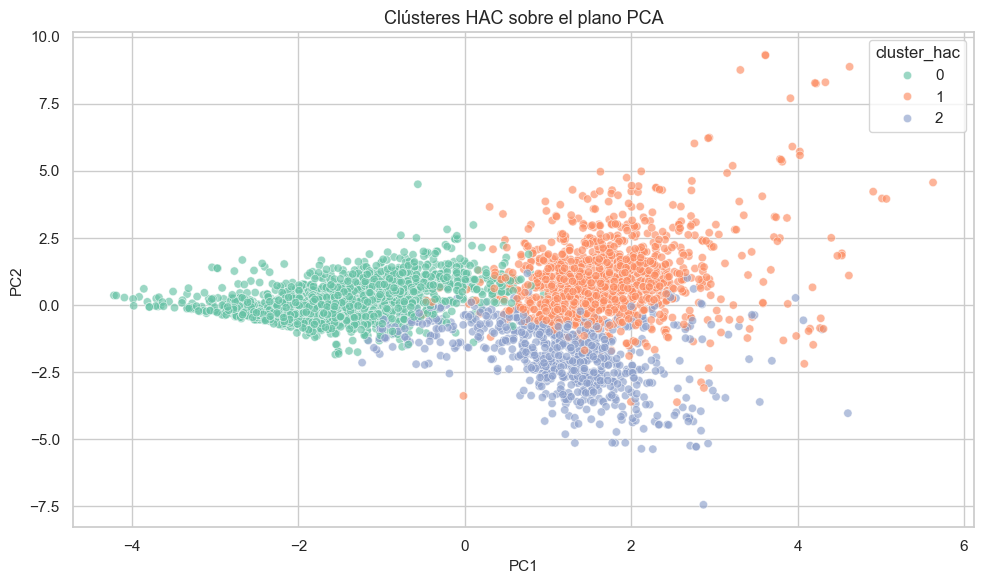

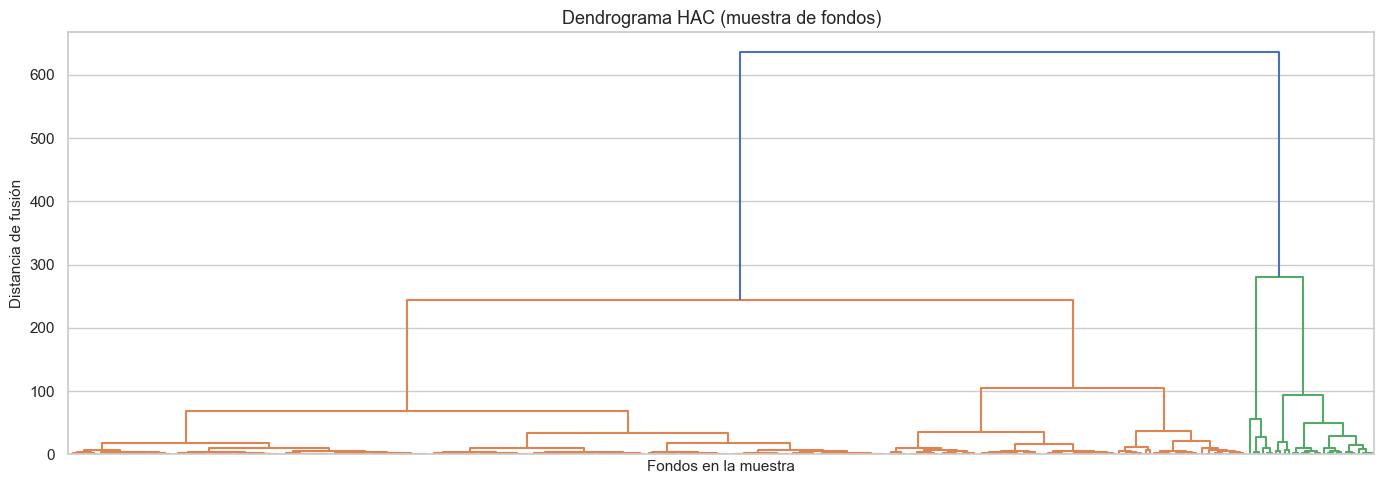

In [8]:
# ==============================================================
# BLOQUE 8: Hierarchical Agglomerative Clustering (HAC)
# ==============================================================
# HAC agrupa observaciones de forma jerárquica, sin depender de centroides.
# Utilizamos enlace Ward porque funciona bien con variables continuas
# estandarizadas y tiende a formar grupos compactos.

hac = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
analysis_df["cluster_hac"] = hac.fit_predict(X)

cluster_profile_hac = analysis_df.groupby("cluster_hac")[profile_cols].median().sort_index()
cluster_sizes_hac = analysis_df["cluster_hac"].value_counts().sort_index().rename("n_fondos")
cluster_profile_hac = cluster_profile_hac.join(cluster_sizes_hac)

print("Tamaño de cada clúster HAC:")
display(cluster_profile_hac)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=analysis_df.sample(min(len(analysis_df), 4000), random_state=42),
    x="PC1",
    y="PC2",
    hue="cluster_hac",
    palette="Set2",
    alpha=0.65
)
plt.title("Clústeres HAC sobre el plano PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# El dendrograma requiere SciPy. Como scikit-learn suele instalarlo como dependencia,
# intentamos mostrar una versión simplificada sobre una muestra para no saturar la figura.
try:
    from scipy.cluster.hierarchy import linkage, dendrogram

    sample_size = min(len(analysis_df), 300)
    dendro_sample = analysis_df.sample(sample_size, random_state=42)
    Z = linkage(dendro_sample[clustering_features].to_numpy(dtype=float), method="ward")

    plt.figure(figsize=(14, 5))
    dendrogram(Z, no_labels=True, color_threshold=None)
    plt.title("Dendrograma HAC (muestra de fondos)")
    plt.xlabel("Fondos en la muestra")
    plt.ylabel("Distancia de fusión")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("No se pudo generar el dendrograma con SciPy:", exc)


## Clustering jerárquico (HAC) y validación de la estructura del universo

Además del algoritmo K-Means, se aplica **Hierarchical Agglomerative Clustering (HAC)** como método alternativo de segmentación.

A diferencia de K-Means:

- HAC **no depende de centroides iniciales**
- Construye una estructura jerárquica de los datos
- Permite analizar la agrupación desde una perspectiva distinta

En este caso se utiliza **enlace Ward**, que minimiza la varianza intra-cluster y es especialmente adecuado para variables continuas estandarizadas.

### 1. Perfil financiero de los clústeres HAC

Los resultados muestran tres grupos con perfiles claramente diferenciados:

#### Clúster 0 — Perfil defensivo

- Baja rentabilidad (`ann_return ≈ 0.02`)
- Baja volatilidad (`ann_vol ≈ 0.05`)
- Baja beta de mercado (`beta_mkt ≈ 0.16`)
- Menor calidad de retorno (Sharpe y Sortino reducidos)

Interpretación:

Este grupo representa fondos **defensivos o de baja intensidad**, con poca exposición al mercado y menor capacidad de generación de retorno.

#### Clúster 1 — Alta exposición al mercado

- Alta beta (`beta_mkt ≈ 0.80`)
- Buen nivel de Sharpe y Sortino
- Mayor drawdown (más negativo)

Interpretación:

Fondos con **perfil agresivo**, altamente dependientes del mercado, pero con un rendimiento ajustado al riesgo razonable.

#### Clúster 2 — Alta eficiencia de retorno

- Mejores valores de Sharpe y Sortino
- Beta moderada (`beta_mkt ≈ 0.51`)
- Menor drawdown relativo

Interpretación:

Fondos con **alta calidad de retorno**, capaces de generar mejores resultados ajustados al riesgo sin una exposición excesiva al mercado.

Adjusted Rand Index entre K-Means y HAC: 0.7794


cluster_hac,0,1,2
cluster_kmeans,,,
0,0.079381,0.892578,0.028041
1,0.002365,0.191142,0.806493
2,0.957817,0.006157,0.036026


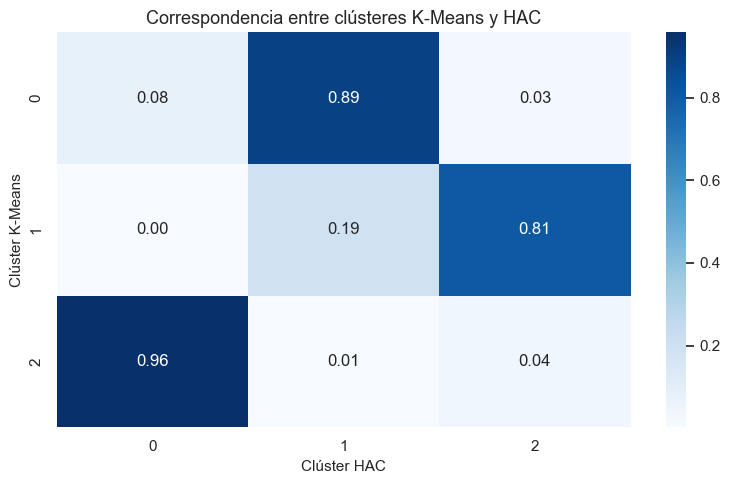

In [9]:
# ==============================================================
# BLOQUE 9: Comparación entre K-Means y HAC
# ==============================================================
# Esta comparación nos permite evaluar si la estructura detectada es robusta
# o si depende demasiado del algoritmo elegido.

ari = adjusted_rand_score(analysis_df["cluster_kmeans"], analysis_df["cluster_hac"])
cross_clusters = pd.crosstab(analysis_df["cluster_kmeans"], analysis_df["cluster_hac"], normalize="index")

print(f"Adjusted Rand Index entre K-Means y HAC: {ari:.4f}")
display(cross_clusters)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_clusters, cmap="Blues", annot=True, fmt=".2f")
plt.title("Correspondencia entre clústeres K-Means y HAC")
plt.xlabel("Clúster HAC")
plt.ylabel("Clúster K-Means")
plt.tight_layout()
plt.show()


## Comparación entre K-Means y HAC: consistencia de la segmentación

Para evaluar la robustez de la segmentación obtenida, se comparan los resultados de K-Means y HAC mediante dos herramientas complementarias:

- **Adjusted Rand Index (ARI)**
- **Matriz de correspondencia entre clústeres**

### 1. Adjusted Rand Index (ARI)

El Adjusted Rand Index mide el grado de acuerdo entre dos particiones del mismo conjunto de datos, corrigiendo por coincidencias aleatorias.

- ARI = 1 → coincidencia perfecta
- ARI = 0 → coincidencia aleatoria
- ARI < 0 → desacuerdo sistemático

En este caso:

> **ARI = 0.7794**

Este valor indica un **alto grado de concordancia** entre K-Means y HAC, lo que sugiere que ambos algoritmos están identificando una estructura similar en el universo de fondos.

No es una coincidencia perfecta, pero está claramente muy por encima de lo que cabría esperar por azar, lo que refuerza la robustez del clustering.

### 2. Matriz de correspondencia entre clústeres

La matriz muestra cómo se distribuyen los fondos de cada clúster de K-Means dentro de los clústeres de HAC.

Cada fila representa un clúster de K-Means y cada columna un clúster de HAC. Los valores indican proporciones.

#### Correspondencias principales:

- **Clúster K-Means 2 ↔ Clúster HAC 0**
  - Coincidencia ≈ **96%**
  - Representa el grupo más claramente definido (perfil defensivo)

- **Clúster K-Means 0 ↔ Clúster HAC 1**
  - Coincidencia ≈ **89%**
  - Grupo de alta exposición al mercado

- **Clúster K-Means 1 ↔ Clúster HAC 2**
  - Coincidencia ≈ **81%**
  - Grupo de alta calidad de retorno

### 3. Interpretación global

Los resultados muestran que:

- Existe una correspondencia casi directa entre los clústeres de ambos métodos
- Las diferencias se concentran en zonas de frontera entre grupos
- La estructura principal (defensivo / agresivo / eficiente) se mantiene estable

Esto indica que la segmentación no es un artefacto del algoritmo, sino que refleja **patrones reales en los datos**.

Clúster K-Means seleccionado para la tesis Asia: 0
Número de fondos en el clúster seleccionado: 7168


,ann_return,ann_vol,sharpe,sortino,max_drawdown,beta_mkt,beta_smb,beta_hml,beta_wml,n_fondos,cluster_candidato_asia
cluster_kmeans,,,,,,,,,,,
0,0.103351,0.175134,0.506499,0.607509,-0.363498,0.800309,0.239367,0.045204,0.022047,7168,1
1,0.142740,0.184061,0.679055,0.799521,-0.329369,0.548316,-0.101925,-0.212637,0.145009,4651,0
2,0.023855,0.053060,0.272201,0.295056,-0.152098,0.156331,0.097150,0.006193,0.006775,12019,0


,allfunds_id,isin,pais_aprox_isin,name_last,cluster_kmeans,beta_mkt,sharpe,max_drawdown
1076,7681,LU0256332296,Luxemburgo,"SCHRODER ISF GLOBAL ENERGY ""A1""",0,1.792090,0.046723,-0.799485
1075,7680,LU0256331488,Luxemburgo,"SCHRODER ISF GLOBAL E ""A"" (USD) A",0,1.792027,0.060524,-0.797606
1078,7683,LU0256331728,Luxemburgo,"SCHRODER ISF GLOBAL ENERGY ""C""",0,1.791521,0.075879,-0.795526
1077,7682,LU0256331561,Luxemburgo,"SCHRODER ISF GLOBAL ENERGY ""B""",0,1.791092,0.044258,-0.799805
12829,147257,LU0671501558,Luxemburgo,"SCHRODER ISF GLOBAL ENERGY ""A"" (EURHDG)",0,1.790507,-0.005540,-0.810839


,pais_aprox_isin,n_fondos,pct_fondos
0,Luxemburgo,5891,0.821847
1,Irlanda,776,0.108259
2,Reino Unido,164,0.022879
3,España,164,0.022879
4,Francia,94,0.013114
5,Alemania,30,0.004185
6,Bélgica,25,0.003488
7,Austria,17,0.002372
8,Finlandia,6,0.000837
9,Países Bajos,1,0.000140


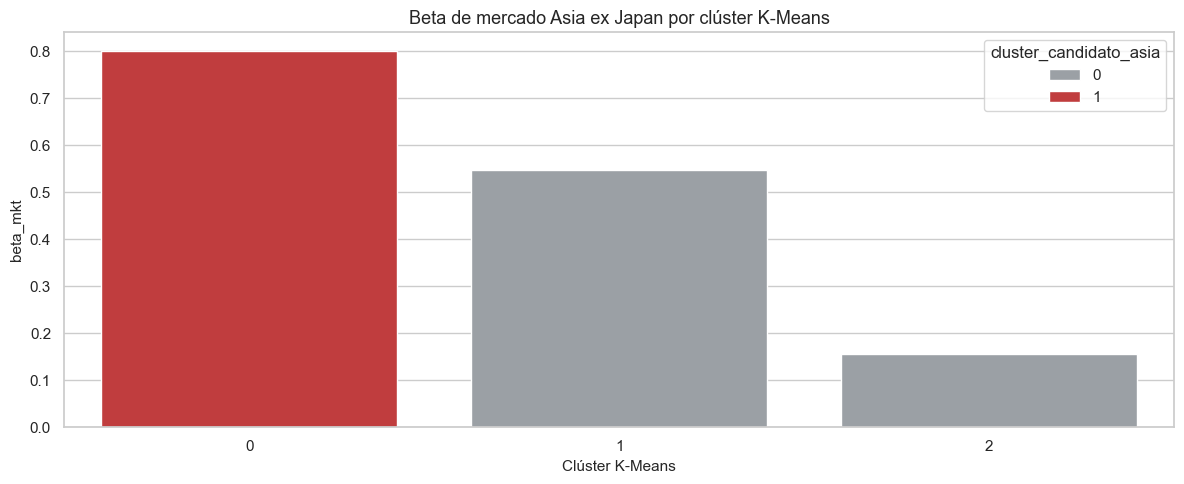

In [16]:
# ==============================================================
# BLOQUE 10: Selección del clúster más expuesto a la tesis Asia
# ==============================================================
# Seleccionamos únicamente el clúster K-Means con mayor beta_mkt,
# ya que representa la mayor sensibilidad al factor Asia ex Japan.

cluster_selection = cluster_profile_kmeans.copy()
selected_cluster = int(cluster_selection["beta_mkt"].idxmax())

cluster_selection["cluster_candidato_asia"] = (
    cluster_selection.index == selected_cluster
).astype(int)
selected_clusters = [selected_cluster]

analysis_df["cluster_candidato_asia"] = (
    analysis_df["cluster_kmeans"] == selected_cluster
).astype(int)

# Ordenamos los fondos del clúster elegido para inspeccionar ejemplos.
# Priorizamos mayor exposición Asia y, a igualdad, mejor Sharpe.
candidate_funds = analysis_df.loc[
    analysis_df["cluster_candidato_asia"] == 1
].copy()
candidate_funds = candidate_funds.sort_values(
    ["beta_mkt", "sharpe", "ann_return"],
    ascending=False
)

num_candidate_funds = len(candidate_funds)

# Si no tenemos una columna explícita de país, usamos el prefijo del ISIN
# como aproximación al país de registro/domicilio legal del vehículo.
isin_country_map = {
    "LU": "Luxemburgo",
    "IE": "Irlanda",
    "FR": "Francia",
    "ES": "España",
    "DE": "Alemania",
    "GB": "Reino Unido",
    "CH": "Suiza",
    "NL": "Países Bajos",
    "IT": "Italia",
    "BE": "Bélgica",
    "AT": "Austria",
    "SE": "Suecia",
    "NO": "Noruega",
    "DK": "Dinamarca",
    "FI": "Finlandia",
    "US": "Estados Unidos",
    "JP": "Japón",
}

candidate_funds["isin_country_code"] = candidate_funds["isin"].astype(str).str[:2].str.upper()
candidate_funds["pais_aprox_isin"] = candidate_funds["isin_country_code"].map(isin_country_map).fillna(candidate_funds["isin_country_code"])

country_summary = (
    candidate_funds["pais_aprox_isin"]
    .value_counts(dropna=False)
    .rename_axis("pais_aprox_isin")
    .reset_index(name="n_fondos")
)
country_summary["pct_fondos"] = country_summary["n_fondos"] / num_candidate_funds

print("Clúster K-Means seleccionado para la tesis Asia:", selected_cluster)
print("Número de fondos en el clúster seleccionado:", num_candidate_funds)

display(cluster_selection.sort_values("beta_mkt", ascending=False))
display(candidate_funds[["allfunds_id", "isin", "pais_aprox_isin", "name_last", "cluster_kmeans", "beta_mkt", "sharpe", "max_drawdown"]].head(5))
display(country_summary)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=cluster_selection.reset_index(),
    x="cluster_kmeans",
    y="beta_mkt",
    hue="cluster_candidato_asia",
    palette={0: "#9aa0a6", 1: "#d62728"}
)
plt.title("Beta de mercado Asia ex Japan por clúster K-Means")
plt.xlabel("Clúster K-Means")
plt.ylabel("beta_mkt")
plt.tight_layout()
plt.show()


## Selección del clúster más expuesto a la tesis Asia

En este bloque se pasa de una lógica de selección basada en múltiples criterios a una regla directa alineada con la tesis de inversión planteada: **identificar el conjunto de fondos con mayor exposición al mercado Asia ex Japan**.

Para ello, se selecciona el clúster de K-Means con mayor valor de `beta_mkt`, ya que esta variable mide la sensibilidad de los fondos al factor de mercado considerado. Este enfoque permite identificar de forma explícita el grupo de fondos más alineado con la hipótesis de que dicho mercado tendrá un buen comportamiento.

### Resultado de la selección

El clúster seleccionado es:

- **Clúster 0**, con una beta media de aproximadamente **0.80**, significativamente superior al resto de clústeres.

Este clúster representa el perfil más expuesto al mercado Asia ex Japan, aunque con ciertas características relevantes:

- Rentabilidad moderada (`ann_return ≈ 0.10`)
- Volatilidad relativamente elevada (`ann_vol ≈ 0.17`)
- Ratio Sharpe inferior al clúster 1
- Mayor severidad en caídas (`max_drawdown` más negativo)

Esto refleja un perfil más agresivo y direccional, coherente con una estrategia de posicionamiento en mercado.

### Universo de fondos seleccionado

El clúster contiene un total de:

- **7.168 fondos**

Estos fondos constituyen el universo candidato para la tesis Asia.

Dentro de este subconjunto, los fondos se ordenan priorizando:

1. Mayor exposición al mercado (`beta_mkt`)
2. Mejor rentabilidad ajustada al riesgo (`sharpe`)
3. Mayor rentabilidad absoluta (`ann_return`)

Esto permite identificar rápidamente los fondos más representativos del clúster.

### Distribución geográfica (aproximada)

A partir del prefijo del ISIN como proxy del país de registro:

- **Luxemburgo** domina claramente (~82%)
- Seguido por:
  - Irlanda (~11%)
  - Reino Unido, España y Francia en menor proporción

Esto es consistente con la estructura habitual de la industria de fondos en Europa, donde Luxemburgo e Irlanda concentran la mayoría de vehículos UCITS.

### Interpretación final

La selección basada en `beta_mkt` permite construir un universo de fondos altamente alineado con la tesis de inversión en Asia ex Japan. No obstante, implica aceptar un mayor nivel de riesgo (volatilidad y drawdowns), lo cual es coherente con una estrategia direccional basada en expectativas de mercado.

In [ ]:
# ==============================================================
# BLOQUE 11: Exportación para Graphext y trazabilidad
# ==============================================================
# Dejamos un dataset ligero y visual para explorar relaciones entre fondos
# fuera del notebook, manteniendo identificadores y variables interpretables.

graphext_export = analysis_df[[
    "allfunds_id",
    "isin",
    "name_last",
    "cluster_kmeans",
    "cluster_hac",
    "cluster_candidato_asia",
    "PC1",
    "PC2",
    "ann_return",
    "ann_vol",
    "sharpe",
    "sortino",
    "max_drawdown",
    "beta_mkt",
    "beta_smb",
    "beta_hml",
    "beta_wml"
]].copy()

graphext_path = DATASET_DIR / "graphext_part2_export.csv"
candidate_path = DATASET_DIR / "fondos_candidatos_part2.csv"

graphext_export.to_csv(graphext_path, index=False, encoding="utf-8")
candidate_funds.to_csv(candidate_path, index=False, encoding="utf-8")

print("Archivo exportado para Graphext:", graphext_path)
print("Archivo exportado con fondos candidatos:", candidate_path)


Archivo exportado para Graphext: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\graphext_part2_export.csv
Archivo exportado con fondos candidatos: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\fondos_candidatos_part2.csv


,allfunds_id,isin,name_last,n_obs,start_date,end_date,ann_return,ann_vol,sharpe,sortino,...,PC7,PC8,PC9,PC10,PC11,cluster_kmeans,cluster_hac,cluster_candidato_asia,isin_country_code,pais_aprox_isin
1076,7681,LU0256332296,"SCHRODER ISF GLOBAL ENERGY ""A1""",1378,2016-01-06,2021-07-16,0.027375,0.367490,0.046723,0.059805,...,0.207320,-0.585975,-0.562125,0.570381,-0.002556,0,1,1,LU,Luxemburgo
1075,7680,LU0256331488,"SCHRODER ISF GLOBAL E ""A"" (USD) A",1378,2016-01-06,2021-07-16,0.032596,0.367447,0.060524,0.077464,...,0.202298,-0.595835,-0.568679,0.559738,-0.002452,0,1,1,LU,Luxemburgo
1078,7683,LU0256331728,"SCHRODER ISF GLOBAL ENERGY ""C""",1378,2016-01-06,2021-07-16,0.038440,0.367479,0.075879,0.097078,...,0.195476,-0.605424,-0.574942,0.547480,-0.002336,0,1,1,LU,Luxemburgo
1077,7682,LU0256331561,"SCHRODER ISF GLOBAL ENERGY ""B""",1378,2016-01-06,2021-07-16,0.026440,0.367375,0.044258,0.056623,...,0.208735,-0.584783,-0.561185,0.571537,-0.002567,0,1,1,LU,Luxemburgo
12829,147257,LU0671501558,"SCHRODER ISF GLOBAL ENERGY ""A"" (EURHDG)",1378,2016-01-06,2021-07-16,0.007833,0.367433,-0.005540,-0.007102,...,0.227036,-0.565571,-0.545474,0.592348,-0.002767,0,1,1,LU,Luxemburgo


### Explicación del bloque

En esta sección se traduce el resultado analítico a un formato operativo. Se el clúster más alineado con la tesis Asia y se guarda en disco.

La exportación para **Graphext** tiene un propósito práctico: facilitar exploración visual, detección de subgrupos y comunicación de resultados.

En la carpeta /dataset se han incluido 3 capturas de pantalla de la herramienta Graphext en la que se ha genrado un grafo de los clúster, un filtro por la carcaterística de mercado y otro filtro del clúster candidato a fondos con sesgo del mercado asiático. Este filtro coincide con uno de los clústeres encontrados por los algoritmso kmeans y HCA, lo que confirma la estructura subyacente de los fondos encontrados.

,ann_return,ann_vol,sharpe,sortino,max_drawdown,ret_skew,ret_kurt,beta_mkt,beta_smb,beta_hml,beta_wml,cluster_kmeans_asignado,cluster_hac_asignado,cluster_kmeans_es_candidato_asia,PC1,PC2
0,0.141728,0.161607,0.759428,0.977735,-0.330058,-0.469513,4.149745,1.01722,0.201399,0.356722,0.118419,0,1,1,1.864282,1.618976


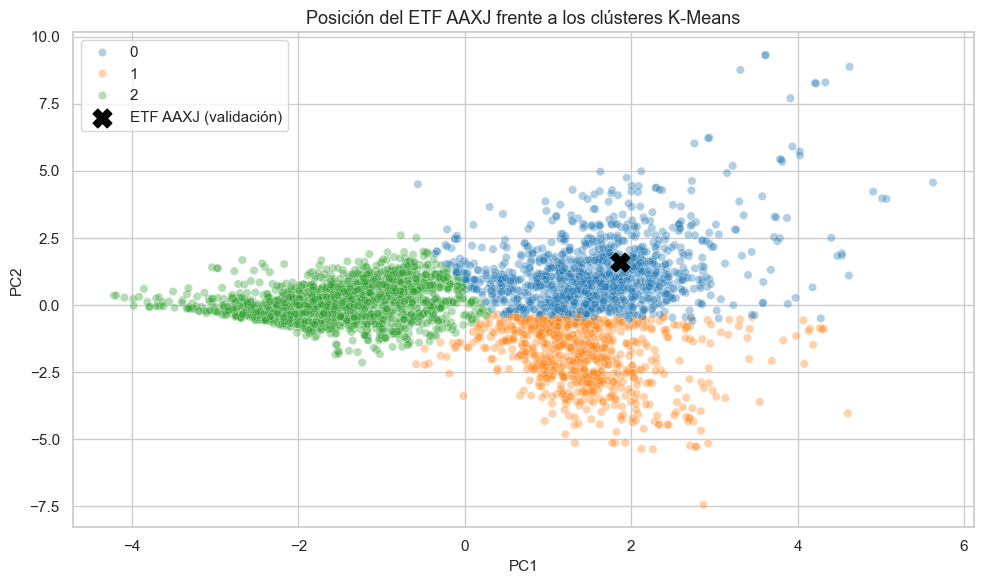

In [17]:
# ==============================================================
# BLOQUE 12: Validación final con el ETF AAXJ (bloque opcional)
# ==============================================================
# Este bloque NO forma parte del pipeline principal de la Parte 2.
# La práctica queda resuelta con los artefactos de la Parte 1 y con el análisis
# no supervisado desarrollado arriba.
#
# Si se quiere hacer la validación final con el ETF AAXJ, la recomendación es:
# - Incorporar una fuente externa y explícita del ETF.
# - Calcular sobre esa serie exactamente las mismas variables que en la Parte 1.
# - Transformarlas con el mismo scaler guardado en `scaler_x_clust_part1.pkl`.
# - Proyectar el ETF en el espacio PCA y asignarlo a los clústeres obtenidos.
#
# Dejamos aquí una plantilla controlada para activar esa validación cuando se
# disponga de una fuente específica del ETF, sin volver a depender de `navs.pickle`.

ENABLE_ETF_VALIDATION = True
ETF_FEATURES_PATH = DATASET_DIR / "aaxj_features_final_test.csv"
scaler_path = DATASET_DIR / xclust_meta["scaler_file"]

if ENABLE_ETF_VALIDATION:
    if not ETF_FEATURES_PATH.exists():
        raise FileNotFoundError(
            "No se encontró `aaxj_features_final_test.csv`. "
            "Para activar esta validación hay que preparar antes las features del ETF."
        )

    etf_feature_row = pd.read_csv(ETF_FEATURES_PATH)

    missing_cols = [col for col in clustering_features if col not in etf_feature_row.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas en el fichero del ETF: {missing_cols}")

    etf_feature_row = etf_feature_row[clustering_features].copy()

    with open(scaler_path, "rb") as f:
        scaler_clust = pickle.load(f)

    etf_scaled = scaler_clust.transform(etf_feature_row)
    etf_pca = pca_full.transform(etf_scaled)
    etf_cluster_kmeans = int(kmeans.predict(etf_scaled)[0])

    hac_centroids = analysis_df.groupby("cluster_hac")[scaled_feature_cols].mean()
    dist_to_hac = ((hac_centroids - etf_scaled[0]) ** 2).sum(axis=1)
    etf_cluster_hac = int(dist_to_hac.idxmin())

    etf_validation = etf_feature_row.copy()
    etf_validation["cluster_kmeans_asignado"] = etf_cluster_kmeans
    etf_validation["cluster_hac_asignado"] = etf_cluster_hac
    etf_validation["cluster_kmeans_es_candidato_asia"] = int(etf_cluster_kmeans in selected_clusters)
    etf_validation["PC1"] = float(etf_pca[0, 0])
    etf_validation["PC2"] = float(etf_pca[0, 1])

    display(etf_validation)

    plt.figure(figsize=(10, 6))
    plot_df = analysis_df.sample(min(len(analysis_df), 4000), random_state=42).copy()
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster_kmeans", palette="tab10", alpha=0.35)
    plt.scatter(etf_pca[0, 0], etf_pca[0, 1], color="black", s=180, marker="X", label="ETF AAXJ (validación)")
    plt.title("Posición del ETF AAXJ frente a los clústeres K-Means")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(
        "Validación final del ETF no ejecutada. "
        "La Parte 2 se apoya solo en las salidas de la Parte 1; "
        "este bloque queda como plantilla opcional para un test final externo."
    )


### Explicación del bloque

La validación final con el ETF queda planteada como **bloque opcional y externo**. Esto refuerza la separación metodológica entre el trabajo principal de la Parte 2, que debe construirse sobre las salidas de la Parte 1, y la comprobación final con AAXJ, que actúa solo como test adicional.

La decisión importante aquí es no reutilizar `navs.pickle` dentro del flujo principal de esta práctica. En su lugar, se deja una plantilla para incorporar un fichero específico de features del ETF, calculadas de forma consistente y transformadas con el mismo escalador de la Parte 1. Así se mantiene la trazabilidad y se evita mezclar la fase de construcción del modelo con una validación externa no imprescindible para resolver el ejercicio principal.


# 2. Discusión Financiera del Tratamiento de Outliers

El endurecimiento del tratamiento de outliers cambia de forma relevante la calidad del análisis no supervisado. Antes de aplicar este filtro, parte de la estructura detectada por K-Means y HAC estaba absorbida por observaciones extremadamente alejadas del centro, lo que generaba clústeres unitarios o casi unitarios. Desde una perspectiva estadística eso ya es una señal de inestabilidad; desde una perspectiva financiera, además, es poco útil porque esos clústeres no describen familias de fondos, sino casos aislados.

La mejora tras el filtrado se ve en varios frentes. Primero, el número de componentes necesarias para explicar una fracción alta de la varianza disminuye, lo que sugiere una estructura más compacta y interpretable. Segundo, el mejor número de clústeres pasa a ser menor y más parsimonioso. Tercero, desaparecen los grupos de tamaño uno, de manera que cada clúster pasa a representar un perfil de inversión reconocible y no una anomalía numérica.

Financieramente, esto fortalece la narrativa de la práctica. Ahora los clústeres pueden leerse como estilos comparables dentro del universo analizado: fondos más defensivos con menor volatilidad y menor exposición, fondos con mayor beta de mercado y rentabilidad media más alta, y fondos con un sesgo factorial más específico y con mejor rentabilidad ajustada al riesgo. Esa lectura es mucho más útil para una tesis de asignación a Asia que una solución contaminada por observaciones extremas.

La decisión también es prudente porque no elimina información sin rastro. Los fondos excluidos quedan guardados en `outliers_clustering_part2.csv`, por lo que la limpieza es auditable. En una memoria académica esto permite argumentar que no se han borrado datos incómodos, sino que se ha separado un subconjunto que no era representativo del objetivo de segmentación principal. Dicho de otro modo: no se niega la existencia de fondos extremos, pero se evita que dicten la geometría de todo el universo.

En consecuencia, la exclusión de outliers debe presentarse como una decisión de robustez y de coherencia económica. Su propósito no es mejorar artificialmente las métricas del algoritmo, sino obtener clústeres que sean más estables, más comparables y más útiles para defender una selección alineada con la tesis de inversión en Asia Pacífico ex Japón.


# 3. Conclusiones

1. La Parte 2 reutiliza de forma coherente la matriz `X_clust` construida en la Parte 1, evitando reescalados indebidos y manteniendo la comparabilidad del análisis.
2. Antes de aplicar PCA y clustering se endureció el tratamiento de outliers en el espacio estandarizado para reducir la aparición de clústeres espurios dominados por observaciones extremas.
3. El PCA reduce la dimensionalidad y ayuda a interpretar qué combinaciones de variables explican mejor la heterogeneidad del universo de fondos.
4. K-Means y HAC aportan dos perspectivas complementarias sobre la estructura no supervisada del conjunto, y su comparación permite evaluar estabilidad.
5. Tras el filtrado robusto, la estructura de clústeres resulta más parsimoniosa, más interpretable y más defendible desde el punto de vista financiero.
6. La selección de clústeres candidatos se apoya en una regla cuantitativa y trazable alineada con la tesis de inversión en Asia Pacífico ex Japón.
7. La validación final con el ETF AAXJ queda separada como bloque opcional y externo, para que el cuerpo principal de la práctica dependa solo de las salidas de la Parte 1.

Si más adelante se incorpora una fuente específica para AAXJ, esa validación deberá discutirse como contraste final del razonamiento, no como parte del proceso de construcción de clústeres.
